# Machine Learning Modeling
This notebook builds and evaluates a Random Forest classifier to predict pain medication effectiveness.

## 1. Import Required Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Load Processed Data

In [2]:
# TODO: Load ML-ready data
processed_data_path = '../data/processed/pain_meds_ml_ready.csv'

df = pd.read_csv(processed_data_path)

print(f"Processed data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns preview:")
print(df.columns.tolist()[:20])  # Show first 20 columns
display(df.head())

Processed data loaded successfully!
Shape: (2473, 61)

Columns preview:
['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'year', 'effectiveness', 'effectiveness_encoded', 'drugName_top', 'condition_top', 'drug_Acetaminophen', 'drug_Acetaminophen / aspirin / caffeine', 'drug_Acetaminophen / butalbital', 'drug_Acetaminophen / butalbital / caffeine', 'drug_Acetaminophen / butalbital / caffeine / codeine', 'drug_Acetaminophen / caffeine / isometheptene mucate', 'drug_Acetaminophen / dichloralphenazone / isometheptene mucate', 'drug_Acetaminophen / diphenhydramine']


,uniqueID,drugName,condition,review,rating,date,usefulCount,year,effectiveness,effectiveness_encoded,drugName_top,condition_top,drug_Acetaminophen,drug_Acetaminophen / aspirin / caffeine,drug_Acetaminophen / butalbital,drug_Acetaminophen / butalbital / caffeine,drug_Acetaminophen / butalbital / caffeine / codeine,drug_Acetaminophen / caffeine / isometheptene mucate,drug_Acetaminophen / dichloralphenazone / isometheptene mucate,drug_Acetaminophen / diphenhydramine,drug_Acetaminophen / hydrocodone,drug_Acetaminophen / oxycodone,drug_Acetaminophen / pamabrom,drug_Acetaminophen / phenyltoloxamine,drug_Advil,drug_Aleve,drug_Aspirin,drug_Aspirin / butalbital / caffeine,drug_Aspirin / butalbital / caffeine / codeine,drug_Celebrex,drug_Diclofenac,drug_Diclofenac / misoprostol,drug_Esomeprazole / naproxen,drug_Famotidine / ibuprofen,drug_Ibuprofen,drug_Indomethacin,drug_Meloxicam,drug_Motrin,drug_Naproxen,drug_Naproxen / sumatriptan,drug_Other,drug_Oxycodone,drug_Tramadol,condition_back pain,condition_chronic pain,condition_cluster headaches,condition_headache,condition_juvenile rheumatoid arthritis,condition_migraine,condition_muscle pain,condition_neck pain,condition_osteoarthritis,condition_rheumatoid arthritis,condition_sciatica,condition_spondyloarthritis,condition_toothache,review_length,review_word_count,has_positive_keywords,has_negative_keywords,avg_word_length
0,1.117185,Oxycodone,chronic pain,"""I&#039;ve been taking oxycodone for roughly 5 years....I&#039;ve gone a few weekends without it...",8,18-Dec-16,-0.202012,0.945890,Effective,2,Oxycodone,chronic pain,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,1.923728,1.763096,0.973265,0.716564,0.140318
1,-0.712322,Aleve,back pain,"""I love Aleve! It makes all my lower back pain disappear, I feel like a new person.""",10,12-Aug-10,0.388791,-1.253626,Effective,2,Aleve,back pain,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,-1.061472,-1.019320,-1.027470,0.716564,-0.846500
2,0.828476,Meloxicam,osteoarthritis,"""I have been using Mobic to relieve the pain from my Spinal Fusion I had in March/2001. I was pr...",10,25-Sep-09,-0.132506,-1.620212,Effective,2,Meloxicam,osteoarthritis,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,-0.586363,-0.563186,-1.027470,0.716564,-0.349654
3,-1.376512,Acetaminophen / oxycodone,chronic pain,"""This med helps to take the edge off enough for the pain to be tolerable. I take HCL 15 mg one e...",6,10-Nov-17,-1.036087,1.312476,Partially Effective,1,Acetaminophen / oxycodone,chronic pain,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,-0.523295,-0.449152,0.973265,0.716564,-0.745493
4,-0.154256,Acetaminophen / butalbital / caffeine,headache,"""I have been suffering from terrible allergies due to hay fever. The allergies caused horrible ...",9,19-Sep-11,-1.036087,-0.887040,Effective,2,Acetaminophen / butalbital / caffeine,headache,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0.035904,-0.152666,0.973265,

## 3. Split into Features (X) and Target (y)

In [3]:
# TODO: Prepare features and target variable
# Define target variable
target_col = 'effectiveness_encoded'

# Define columns to exclude from features
exclude_cols = [
    'effectiveness', 'effectiveness_encoded', 'rating',
    'drugName', 'condition', 'drugName_top', 'condition_top', 
    'review', 'date'  # Add any other non-feature columns
]

# Get feature columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Create X (features) and y (target)
X = df[feature_cols]
y = df[target_col]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nNumber of features: {len(feature_cols)}")
print(f"\nTarget distribution:")
print(y.value_counts().sort_index())
print("\nTarget class percentages:")
print(y.value_counts(normalize=True).sort_index() * 100)

Features (X) shape: (2473, 52)
Target (y) shape: (2473,)

Number of features: 52

Target distribution:
effectiveness_encoded
0     410
1     275
2    1788
Name: count, dtype: int64

Target class percentages:
effectiveness_encoded
0    16.579054
1    11.120097
2    72.300849
Name: proportion, dtype: float64


## 4. Train/Test Split (80/20, Stratified)

In [4]:
# TODO: Split data into train and test sets
# Use stratified split to maintain class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Data split complete!")
print("=" * 60)
print(f"Training set size: {len(X_train):,} ({(len(X_train)/len(X))*100:.1f}%)")
print(f"Test set size: {len(X_test):,} ({(len(X_test)/len(X))*100:.1f}%)")
print("\nTraining set target distribution:")
print(y_train.value_counts(normalize=True).sort_index() * 100)
print("\nTest set target distribution:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

Data split complete!
Training set size: 1,978 (80.0%)
Test set size: 495 (20.0%)

Training set target distribution:
effectiveness_encoded
0    16.582406
1    11.122346
2    72.295248
Name: proportion, dtype: float64

Test set target distribution:
effectiveness_encoded
0    16.565657
1    11.111111
2    72.323232
Name: proportion, dtype: float64


## 5. Train Random Forest Classifier

In [5]:
# TODO: Train Random Forest model
print("Training Random Forest Classifier...")

# Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=20,          # Maximum depth of trees
    min_samples_split=10,  # Minimum samples to split a node
    min_samples_leaf=5,    # Minimum samples at leaf node
    random_state=42,
    n_jobs=-1,             # Use all processors
    verbose=1
)

# Train the model
rf_model.fit(X_train, y_train)

print("\nModel training complete!")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Number of features used: {rf_model.n_features_in_}")
print(f"Number of classes: {len(rf_model.classes_)}")

Training Random Forest Classifier...

Model training complete!
Number of trees: 100
Number of features used: 52
Number of classes: 3


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished


## 6. Make Predictions and Get Probabilities

In [6]:
# TODO: Generate predictions on test set
print("Generating predictions...")

# Predictions on training set
y_train_pred = rf_model.predict(X_train)
y_train_proba = rf_model.predict_proba(X_train)

# Predictions on test set
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)

print("Predictions generated!")
print(f"\nTraining set predictions shape: {y_train_pred.shape}")
print(f"Test set predictions shape: {y_test_pred.shape}")
print(f"Probability matrix shape: {y_test_proba.shape}")

# Display sample predictions with probabilities
print("\nSample predictions:")
sample_results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_test_pred[:10],
    'Prob_Class_0': y_test_proba[:10, 0],
    'Prob_Class_1': y_test_proba[:10, 1],
    'Prob_Class_2': y_test_proba[:10, 2]
})
display(sample_results)

Generating predictions...


Predictions generated!

Training set predictions shape: (1978,)
Test set predictions shape: (495,)
Probability matrix shape: (495, 3)

Sample predictions:


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.0s finished


,Actual,Predicted,Prob_Class_0,Prob_Class_1,Prob_Class_2
0,2,2,0.195340,0.125262,0.679398
1,0,2,0.323612,0.116814,0.559575
2,2,2,0.104885,0.134447,0.760668
3,2,2,0.135024,0.108846,0.756130
4,2,2,0.027975,0.072477,0.899548
5,0,2,0.089427,0.091781,0.818792
6,2,2,0.239383,0.183582,0.577034
7,2,2,0.116973,0.156768,0.726259
8,0,2,0.349934,0.203527,0.446539
9,2,2,0.020730,0.100644,0.878626


## 7. Calculate Metrics (Accuracy, Confusion Matrix, Classification Report)

MODEL PERFORMANCE METRICS

Training Accuracy: 0.7796 (77.96%)
Test Accuracy: 0.7192 (71.92%)

Test Precision: 0.5961
Test Recall: 0.7192
Test F1-Score: 0.6363

CONFUSION MATRIX
[[ 10   0  72]
 [  5   0  50]
 [ 12   0 346]]


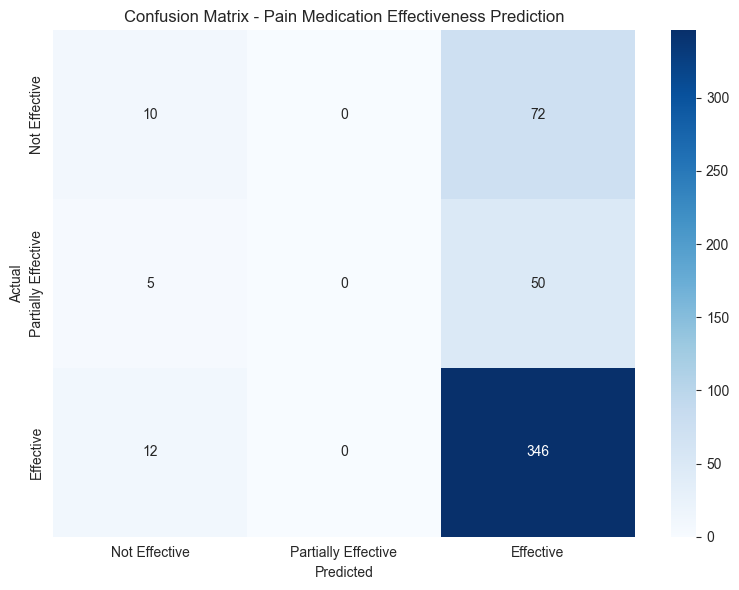


CLASSIFICATION REPORT
                         precision    recall  f1-score   support

      Not Effective (0)       0.37      0.12      0.18        82
Partially Effective (1)       0.00      0.00      0.00        55
          Effective (2)       0.74      0.97      0.84       358

               accuracy                           0.72       495
              macro avg       0.37      0.36      0.34       495
           weighted avg       0.60      0.72      0.64       495



In [7]:
# TODO: Calculate and display model performance metrics
print("=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)

# Training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

# Test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Additional metrics
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nTest Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

# Confusion Matrix
print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Effective', 'Partially Effective', 'Effective'],
            yticklabels=['Not Effective', 'Partially Effective', 'Effective'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Pain Medication Effectiveness Prediction')
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
class_names = ['Not Effective (0)', 'Partially Effective (1)', 'Effective (2)']
print(classification_report(y_test, y_test_pred, target_names=class_names))

## 8. Feature Importance Analysis

Analyzing feature importance...

Top 20 Most Important Features:


,feature,importance
1,usefulCount,0.181846
0,uniqueID,0.135974
2,year,0.135847
51,avg_word_length,0.108989
47,review_length,0.100777
48,review_word_count,0.093684
49,has_positive_keywords,0.031335
33,drug_Tramadol,0.030006
37,condition_headache,0.023244
29,drug_Naproxen,0.018346


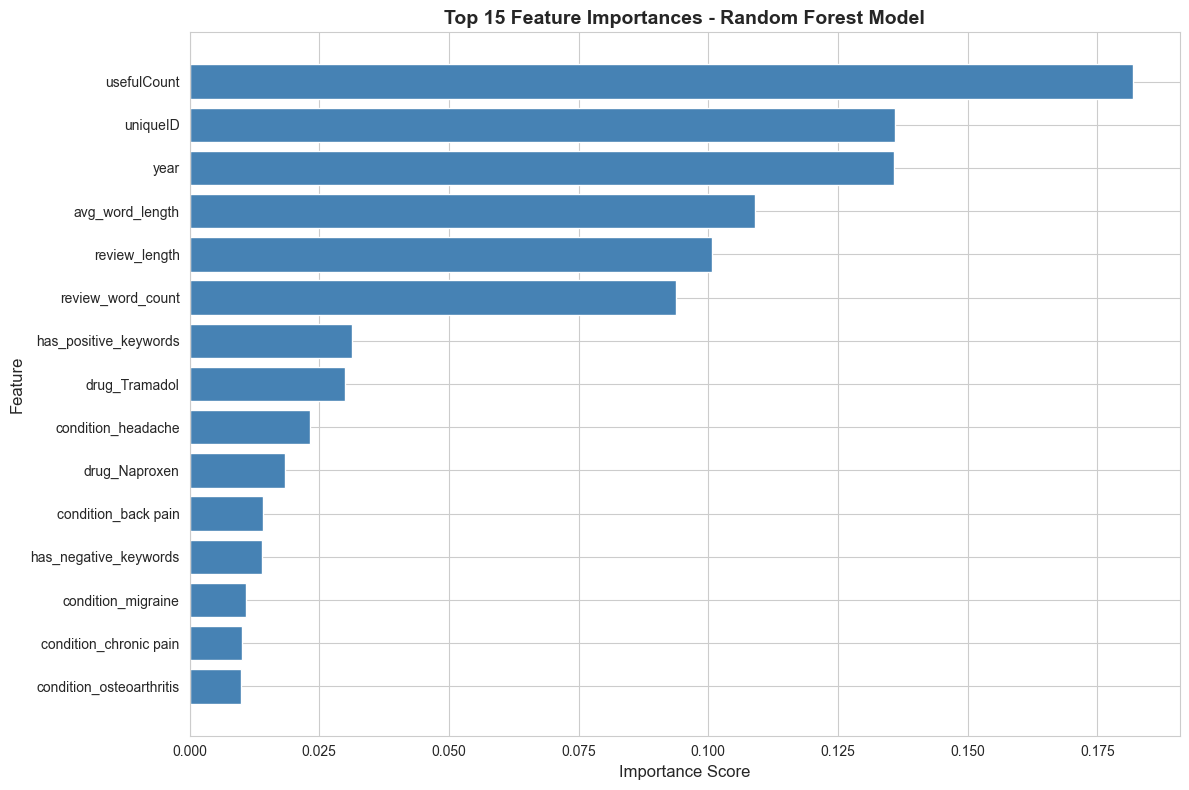


Total features: 52
Features with importance > 0.01: 14
Features with importance > 0.05: 6


In [8]:
# TODO: Analyze feature importance
print("Analyzing feature importance...")

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Display top 20 features
print("\nTop 20 Most Important Features:")
print("=" * 60)
display(feature_importance.head(20))

# Visualize top 15 features
plt.figure(figsize=(12, 8))
top_15 = feature_importance.head(15)
plt.barh(range(len(top_15)), top_15['importance'].values, color='steelblue')
plt.yticks(range(len(top_15)), top_15['feature'].values)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Feature Importances - Random Forest Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nTotal features: {len(feature_importance)}")
print(f"Features with importance > 0.01: {len(feature_importance[feature_importance['importance'] > 0.01])}")
print(f"Features with importance > 0.05: {len(feature_importance[feature_importance['importance'] > 0.05])}")

## 9. Save Model

In [9]:
# TODO: Save trained model to file
model_output_path = '../outputs/models/rf_model.pkl'

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(model_output_path), exist_ok=True)

# Save model using pickle
with open(model_output_path, 'wb') as f:
    pickle.dump(rf_model, f)

print(f"Model saved to: {model_output_path}")

# Also save feature names for later use
feature_names_path = '../outputs/models/feature_names.pkl'
with open(feature_names_path, 'wb') as f:
    pickle.dump(feature_cols, f)

print(f"Feature names saved to: {feature_names_path}")

# Save feature importance
feature_importance_path = '../outputs/models/feature_importance.csv'
feature_importance.to_csv(feature_importance_path, index=False)
print(f"Feature importance saved to: {feature_importance_path}")

# Save test predictions for analysis
test_results_path = '../outputs/models/test_predictions.csv'
test_results = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_test_pred,
    'prob_not_effective': y_test_proba[:, 0],
    'prob_partially_effective': y_test_proba[:, 1],
    'prob_effective': y_test_proba[:, 2]
})
test_results.to_csv(test_results_path, index=False)
print(f"Test predictions saved to: {test_results_path}")

print("\n" + "=" * 60)
print("MODELING COMPLETE")
print("=" * 60)
print(f"Final Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Model and results saved successfully!")
print("=" * 60)

Model saved to: ../outputs/models/rf_model.pkl
Feature names saved to: ../outputs/models/feature_names.pkl
Feature importance saved to: ../outputs/models/feature_importance.csv
Test predictions saved to: ../outputs/models/test_predictions.csv

MODELING COMPLETE
Final Test Accuracy: 0.7192 (71.92%)
Model and results saved successfully!
